In [6]:
import geopandas as gpd
from shapely.geometry import box
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import numpy as np
from shapely.geometry import MultiPolygon, Polygon
import pandas as pd
import geopandas as gpd
from shapely import wkt
from tqdm import tqdm

In [2]:
def get_tiff_bounds(tiff_path):
    # Open the TIFF file
    with rasterio.open(tiff_path) as dataset:
        # Get the bounds of the TIFF file
        bounds = dataset.bounds
        print(f"Bounds of {tiff_path}:")
        print(f"Left: {bounds.left}, Bottom: {bounds.bottom}, Right: {bounds.right}, Top: {bounds.top}")
        return bounds

def create_grid(bounds, cell_size):
   
    # Define the extent of the USA (example bounding box)
    extent = (bounds.left, bounds.bottom, bounds.right, bounds.top)

    # Calculate the side length of the square based on the area (0.034 square units)
    side_length = np.sqrt(cell_size)

    # Generate grid of polygons covering the USA extent
    grid_polygons = []
    minx, miny, maxx, maxy = extent
    x_steps = int(np.ceil((maxx - minx) / side_length))
    y_steps = int(np.ceil((maxy - miny) / side_length))

    for x in range(x_steps):
        for y in range(y_steps):
            polygon = Polygon([(minx + x * side_length, miny + y * side_length),
                            (minx + (x + 1) * side_length, miny + y * side_length),
                            (minx + (x + 1) * side_length, miny + (y + 1) * side_length),
                            (minx + x * side_length, miny + (y + 1) * side_length)])
            grid_polygons.append(polygon)

    # Create a GeoDataFrame from the list of polygons
    grid_gdf = gpd.GeoDataFrame(geometry=grid_polygons, crs='EPSG:4326')
    
    return grid_gdf

In [3]:

TCC_path_2017 = "/Net/Groups/BGI/work_2/ForExD/WP1/Data/nlcd_tcc_CONUS_2017_v2021-4/wp1_nlcd_tcc_conus_2017_v2021_4_20m_4326_cropped_region_08.tif"
bounds = get_tiff_bounds(TCC_path_2017)

    
# Step 2: Create a grid based on these bounds with a cell size of 0.42 degrees
cell_size = 0.043
grid_gdf = create_grid(bounds, cell_size)

# Step 3: Save the grid as a shapefile
output_path = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/grid.shp"
grid_gdf.to_file(output_path)
print(f"Saved grid to {output_path}")
print(f"Amount of grids {len(grid_gdf)}")

Bounds of /Net/Groups/BGI/work_2/ForExD/WP1/Data/nlcd_tcc_CONUS_2017_v2021-4/wp1_nlcd_tcc_conus_2017_v2021_4_20m_4326_cropped_region_08.tif:
Left: -100.0, Bottom: 25.0, Right: -75.0, Top: 40.0
Saved grid to /Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/grid.shp
Amount of grids 8833


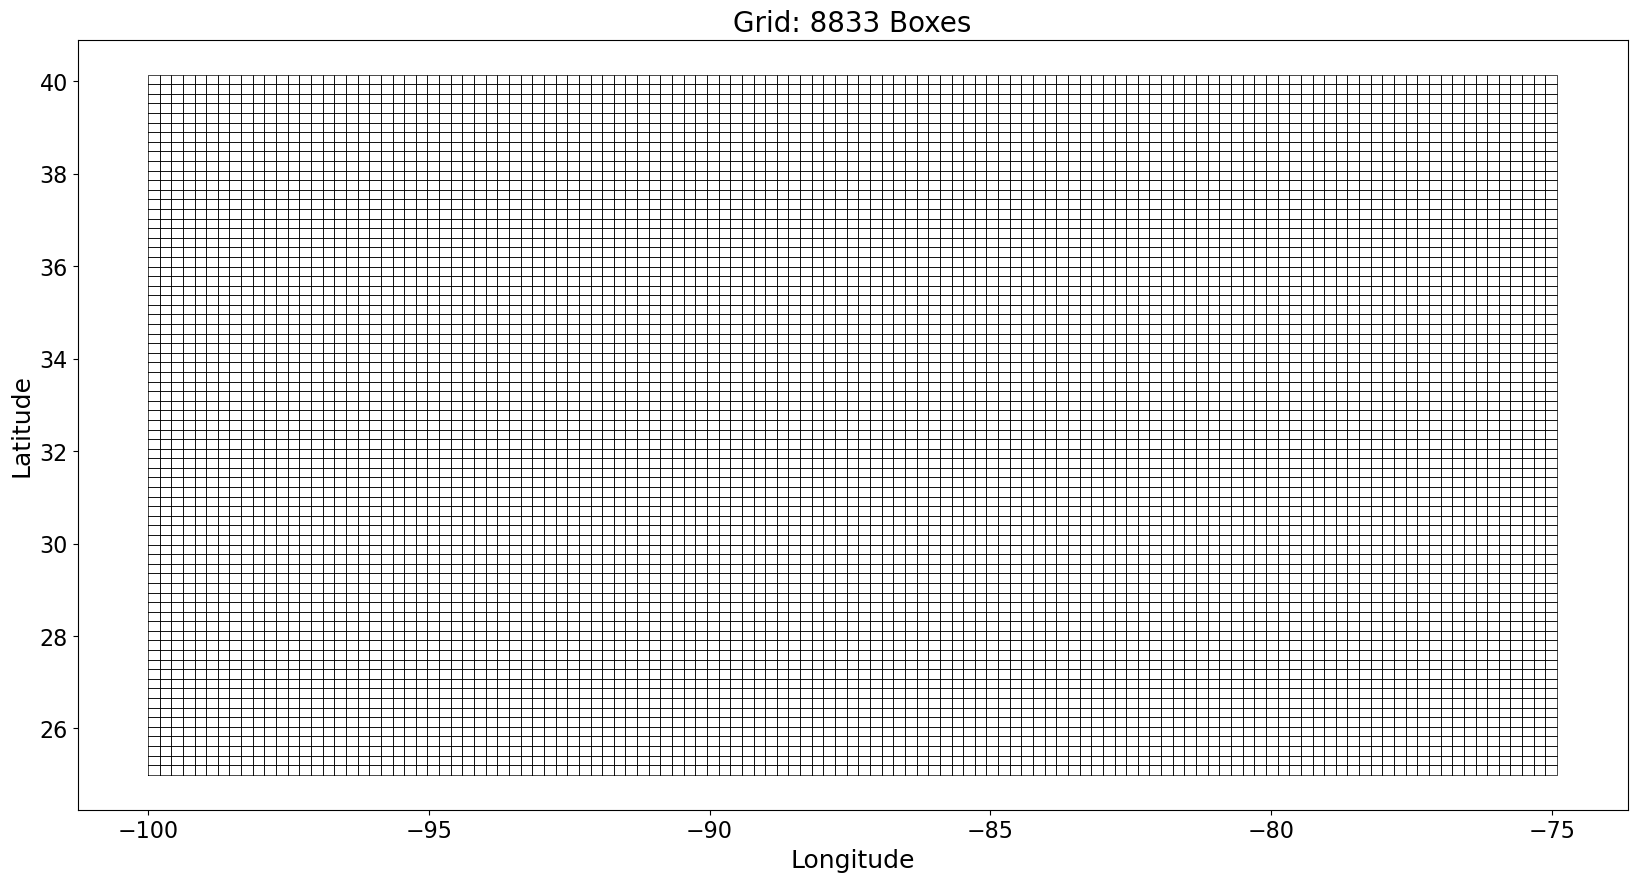

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_grid(grid_gdf):
    # Create a plot
    fig, ax = plt.subplots(figsize=(20, 10))
    
    # Plot grid cells as lines
    for geom in grid_gdf.geometry:
        x, y = geom.exterior.xy
        ax.plot(x, y, color='black', linewidth=0.5)
    
    ax.set_title(f"Grid: {len(grid_gdf)} Boxes", fontsize=20)  # Adjust title fontsize
    ax.set_xlabel('Longitude', fontsize=18)  # Adjust xlabel fontsize
    ax.set_ylabel('Latitude', fontsize=18)   # Adjust ylabel fontsize
    
    # Adjust tick label fontsize
    ax.tick_params(axis='both', which='major', labelsize=16)
    
    plt.show()

# Step 3: Plot the grid
plot_grid(grid_gdf)


In [5]:
refdm_path = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/radar_enhanced_forest_disturbance_mapping.shp"
ids_path = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/region8_dca_filtered_ids_usda_polygons.csv"

# Step 1: Load the REFDM shapefile and USDA polygons CSV file
print("Step 5.1: Load the REFDM shapefile and USDA polygons CSV file")
refdm_gdf = gpd.read_file(refdm_path)
ids_usda = pd.read_csv(ids_path)
ids_usda['geometry'] = ids_usda['geometry'].apply(wkt.loads)
ids_gdf = gpd.GeoDataFrame(ids_usda, geometry='geometry')

# Ensure CRS match
if refdm_gdf.crs is None:
    print("Warning: REFDM GeoDataFrame has no CRS. Assuming WGS 84.")
    refdm_gdf = refdm_gdf.set_crs("EPSG:4326")

if ids_gdf.crs is None:
    print("Warning: USDA GeoDataFrame has no CRS. Assuming WGS 84.")
    ids_gdf = ids_gdf.set_crs("EPSG:4326")

if refdm_gdf.crs != ids_gdf.crs:
    print("CRS mismatch detected. Reprojecting USDA polygons to match REFDM CRS.")
    ids_gdf = ids_gdf.to_crs(refdm_gdf.crs)


Step 5.1: Load the REFDM shapefile and USDA polygons CSV file
CRS mismatch detected. Reprojecting USDA polygons to match REFDM CRS.


In [8]:
# Step 2: Dissolve REFDM polygons by 'USDA_IDX'
print("Step 5.2: Dissolving the REFDM polygons by 'USDA_IDX'")
dissolved_refdm = refdm_gdf.dissolve(by='USDA_IDX').reset_index()

# Step 3: Spatial join to intersect dissolved REFDM with USDA polygons
print("Step 5.3: Intersecting USDA polygons with dissolved REFDM")
merged_gdf = gpd.sjoin(dissolved_refdm, ids_gdf, how='left', predicate='intersects')

Step 5.2: Dissolving the REFDM polygons by 'USDA_IDX'
Step 5.3: Intersecting USDA polygons with dissolved REFDM


In [11]:
# Keep only 'geometry' and 'USDA_IDX' columns
merged_gdf = merged_gdf[['geometry', 'USDA_IDX']]

In [12]:
merged_gdf

,geometry,USDA_IDX
0,"MULTIPOLYGON (((-86.09993 32.13959, -86.09973 ...",bark_beetle_2017_0
0,"MULTIPOLYGON (((-86.09993 32.13959, -86.09973 ...",bark_beetle_2017_0
1,"MULTIPOLYGON (((-86.02044 32.00757, -86.02006 ...",bark_beetle_2017_1
1,"MULTIPOLYGON (((-86.02044 32.00757, -86.02006 ...",bark_beetle_2017_1
2,"MULTIPOLYGON (((-86.99148 32.66153, -86.99129 ...",bark_beetle_2017_10
...,...,...
16515,"MULTIPOLYGON (((-88.52876 36.07517, -88.52876 ...",wind_2020_19407
16516,"MULTIPOLYGON (((-85.85410 36.14892, -85.85430 ...",wind_2020_19408
16517,"MULTIPOLYGON (((-85.44797 36.10154, -85.44836 ...",wind_2020_19410
16518,"MULTIPOLYGON (((-85.02410 36.13508, -85.02429 ...",wind_2020_19412


In [14]:
# Step 4: Create convex hulls from the dissolved geometries
print("Step 5.4: Creating convex hulls from dissolved geometries")
dissolved_merged_gdf = merged_gdf.dissolve(by='USDA_IDX')

Step 5.4: Creating convex hulls from dissolved geometries


In [17]:
dissolved_merged_gdf = dissolved_merged_gdf.reset_index()
dissolved_merged_gdf

,USDA_IDX,geometry
0,bark_beetle_2017_0,"MULTIPOLYGON (((-86.09973 32.13959, -86.09973 ..."
1,bark_beetle_2017_1,"MULTIPOLYGON (((-86.02044 32.00718, -86.02044 ..."
2,bark_beetle_2017_10,"MULTIPOLYGON (((-86.99148 32.65959, -86.99148 ..."
3,bark_beetle_2017_100,"MULTIPOLYGON (((-86.13072 32.05260, -86.13110 ..."
4,bark_beetle_2017_1000,"MULTIPOLYGON (((-88.88281 34.07266, -88.88281 ..."
...,...,...
16515,wind_2020_19407,"MULTIPOLYGON (((-88.52876 36.07517, -88.52876 ..."
16516,wind_2020_19408,"MULTIPOLYGON (((-85.85430 36.14892, -85.85430 ..."
16517,wind_2020_19410,"MULTIPOLYGON (((-85.44875 36.10154, -85.44856 ..."
16518,wind_2020_19412,"MULTIPOLYGON (((-85.02410 36.13527, -85.02410 ..."


In [29]:
print("Step 5.5: Creating convex hulls ....")
convex_hulls = []
for geom in tqdm(dissolved_merged_gdf['geometry'], desc="Creating convex hulls", unit="hull"):
    convex_hulls.append(MultiPolygon([geom.convex_hull]))

convex_hulls_gdf = gpd.GeoDataFrame(geometry=convex_hulls, crs=refdm_gdf.crs).reset_index()

convex_hulls_gdf

Step 5.5: Creating convex hulls ....


Creating convex hulls: 100%|██████████| 16520/16520 [00:07<00:00, 2257.43hull/s]


,index,geometry
0,0,"MULTIPOLYGON (((-86.08953 32.13766, -86.09877 ..."
1,1,"MULTIPOLYGON (((-86.01467 32.00506, -86.01698 ..."
2,2,"MULTIPOLYGON (((-86.99129 32.65939, -86.99226 ..."
3,3,"MULTIPOLYGON (((-86.12899 32.05144, -86.13303 ..."
4,4,"MULTIPOLYGON (((-88.87002 34.04708, -88.88068 ..."
...,...,...
16515,16515,"MULTIPOLYGON (((-88.52876 36.07517, -88.53250 ..."
16516,16516,"MULTIPOLYGON (((-85.85430 36.14892, -85.85898 ..."
16517,16517,"MULTIPOLYGON (((-85.44875 36.10135, -85.44973 ..."
16518,16518,"MULTIPOLYGON (((-84.99426 36.12806, -85.00986 ..."


In [31]:
convex_hulls_gdf.crs

<Geographic 2D CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84" ...>
Name: WGS 84
Axis Info [ellipsoidal]:
- lon[east]: Longitude (Degree)
- lat[north]: Latitude (Degree)
Area of Use:
- undefined
Datum: World Geodetic System 1984
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [32]:
# Ensure CRS match before spatial join
if grid_gdf.crs != convex_hulls_gdf.crs:
    print("CRS mismatch detected between grid and convex hulls. Reprojecting grid to match convex hulls CRS.")
    grid_gdf = grid_gdf.to_crs(convex_hulls_gdf.crs)

# Step 5: Find grid cells intersecting with convex hulls
print("Step 5.5: Finding grid cells intersecting with convex hulls")
intersected_gdf = gpd.sjoin(grid_gdf, convex_hulls_gdf, how='inner', predicate='intersects')
intersected_gdf = intersected_gdf.drop(columns=['index_right']).drop_duplicates().reset_index(drop=True)


Step 5.5: Finding grid cells intersecting with convex hulls


In [35]:
# Step 5: Find grid cells intersecting with convex hulls
print("Step 5.5: Finding grid cells intersecting with convex hulls")
intersected_gdf = gpd.sjoin(grid_gdf, convex_hulls_gdf, how='inner', predicate='intersects')
intersected_gdf = intersected_gdf.drop(columns=['index_right',"index"]).drop_duplicates().reset_index(drop=True)

# Output the number of intersected grids
print(f"Amount of Grids: {len(intersected_gdf)}")

Step 5.5: Finding grid cells intersecting with convex hulls
Amount of Grids: 740


In [38]:
import xarray as xr
from shapely.geometry import Polygon

# Path to your NetCDF file
#nc_file = "/Net/Groups/BGI/scratch/fmueller/Data/s2/1024/0/0_2018.nc"
nc_file = "/Net/Groups/BGI/scratch/fmueller/Data/s2_minicubes/0/0_2018.nc"

# Load the NetCDF file using xarray
ds = xr.open_dataset(nc_file)

# Extract latitude and longitude coordinates
lon = ds.variables['lon'][:]
lat = ds.variables['lat'][:]

# Assuming lon and lat are 1D arrays representing grid coordinates
# Create a Polygon from the exterior coordinates
exterior_coords = [(lon[0], lat[0]), (lon[-1], lat[0]), (lon[-1], lat[-1]), (lon[0], lat[-1])]
polygon = Polygon(exterior_coords)

# Print the created Polygon
print("Polygon from exterior coordinates:")
polygon.area

Polygon from exterior coordinates:


0.04327084055081362

In [39]:
ds

<xarray.Dataset>
Dimensions:   (time: 69, lon: 1024, lat: 1024)
Coordinates:
  * time      (time) datetime64[ns] 2018-01-02 2018-01-07 ... 2018-12-28
  * lon       (lon) float64 -95.8 -95.8 -95.8 -95.8 ... -95.57 -95.57 -95.57
  * lat       (lat) float64 34.5 34.5 34.5 34.5 34.5 ... 34.31 34.31 34.31 34.31
    angle     object ...
Data variables: (12/15)
    s2_SCL    (time, lat, lon) float64 ...
    s2_mask   (time, lat, lon) float64 ...
    s2_avail  (time) float32 ...
    s2_B01    (time, lat, lon) float64 ...
    s2_B02    (time, lat, lon) float64 ...
    s2_B03    (time, lat, lon) float64 ...
    ...        ...
    s2_B07    (time, lat, lon) float64 ...
    s2_B08    (time, lat, lon) float64 ...
    s2_B8A    (time, lat, lon) float64 ...
    s2_B09    (time, lat, lon) float64 ...
    s2_B11    (time, lat, lon) float64 ...
    s2_B12    (time, lat, lon) float64 ...
Attributes:
    history:  Created on 2024-06-07 23:49:35.839057 with the earthnet-minicub...

In [40]:
import geopandas as gpd
from shapely.geometry import MultiPolygon
import pandas as pd
import pandas as pd
import geopandas as gpd
from shapely import wkt

# Load refdm dataset
refdm_path = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/radar_enhanced_forest_disturbance_mapping.shp"
refdm_gdf = gpd.read_file(refdm_path)

# Load ids dataset
ids_path = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/region8_dca_filtered_ids_usda_polygons.csv"
ids_usda = pd.read_csv(ids_path)
# Step 2: Convert the WKT geometries to Shapely geometries
print("     Converting WKT geometries...")
ids_usda['geometry'] = ids_usda['geometry'].apply(wkt.loads)
# Step 3: Convert the DataFrame to a GeoDataFrame
print("     Converting DataFrame to GeoDataFrame...")
ids_gdf = gpd.GeoDataFrame(ids_usda, geometry='geometry')
ids_gdf

     Converting WKT geometries...
     Converting DataFrame to GeoDataFrame...


,index_usda,DCA_ID,SURVEY_YEAR,REGION_ID,DAMAGE_TYPE,DAMAGE_TYPE_CODE,DCA_CODE,DA_Code_USDA,PERCENT_AFFECTED,HOST,HOST_CODE,cluster_id,geometry,area_km2
0,bark_beetle_2017_0,bark_beetle,2017,8,Mortality,2,11003,1,No Data,NaN,-1.0,14245,"POLYGON ((-86.09680 32.14270, -86.09685 32.142...",0.005641
1,bark_beetle_2017_1,bark_beetle,2017,8,Mortality,2,11003,1,No Data,NaN,-1.0,14246,"POLYGON ((-86.01648 32.01100, -86.01655 32.011...",0.011262
2,bark_beetle_2017_2,bark_beetle,2017,8,Mortality,2,11003,1,No Data,NaN,-1.0,14247,"POLYGON ((-86.24623 32.06300, -86.24629 32.063...",0.011274
3,bark_beetle_2017_3,bark_beetle,2017,8,Mortality,2,11003,1,No Data,NaN,-1.0,14248,"POLYGON ((-86.08565 32.05823, -86.08572 32.058...",0.011273
4,bark_beetle_2017_4,bark_beetle,2017,8,Mortality,2,11003,1,No Data,NaN,-1.0,14249,"POLYGON ((-87.40289 32.86707, -87.40294 32.867...",0.005732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19188,wind_2020_19407,wind,2020,8,Main stem Broken or Uprooted,7,50013,16,Severe (30-50%),NaN,NaN,19838,"POLYGON ((-88.36541 36.09120, -88.26354 36.080...",7.410090
19189,wind_2020_19408,wind,2020,8,Main stem Broken or Uprooted,7,50013,16,Moderate (11-29%),NaN,NaN,19839,"POLYGON ((-85.81513 36.15473, -85.84284 36.152...",1.494372
19190,wind_2020_19410,wind,2020,8,Main stem Broken or Uprooted,7,50013,16,Moderate (11-29%),NaN,NaN,19841,"POLYGON ((-85.44200 36.10658, -85.44203 36.106...",0.031742
19191,wind_2020_19412,wind,2020,8,Main stem Broken or Uprooted,7,50013,16,Moderate (11-29%),NaN,NaN,19843,"POLYGON ((-85.02250 36.14265, -84.99754 36.137...",1.906103


In [54]:
refdm_gdf

,USDA_IDX,S1_YEAR,S1_TILE,S1CD_IDX,DCA_ID,SURV_YEAR,REG_ID,DAM_TYPE,DAM_TYPE_C,DCA_CD,DA_CD_USDA,PCT_AFFECT,HOST,HOST_CODE,cluster_id,area_km2,geometry
0,bark_beetle_2019_12801,2020,E084N024T3,12620,bark_beetle,2019,8,Mortality,2,11030,1,Light (4-10%),None,None,12360,0.368559,"MULTIPOLYGON (((-94.92155 31.15265, -94.92155 ..."
1,bark_beetle_2019_12802,2020,E084N024T3,12621,bark_beetle,2019,8,Mortality,2,11030,1,Light (4-10%),None,None,12360,0.126797,"MULTIPOLYGON (((-94.92386 31.15708, -94.92367 ..."
2,bark_beetle_2019_12803,2020,E084N024T3,12622,bark_beetle,2019,8,Mortality,2,11030,1,Light (4-10%),None,None,12360,0.298717,"MULTIPOLYGON (((-94.91750 31.15130, -94.91712 ..."
3,bark_beetle_2019_12804,2020,E084N024T3,12623,bark_beetle,2019,8,Mortality,2,11030,1,Light (4-10%),None,None,12360,0.260585,"MULTIPOLYGON (((-94.91558 31.15554, -94.91558 ..."
4,bark_beetle_2019_12805,2020,E084N024T3,12624,bark_beetle,2019,8,Mortality,2,11030,1,Very Light (1-3%),None,None,18275,0.636185,"MULTIPOLYGON (((-94.90383 31.16151, -94.90325 ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40865,wind_2019_11704,2019,E093N027T3,11533,wind,2019,8,Main stem Broken or Uprooted,7,50013,16,Very Severe (>50%),No host tree,9997,18127,0.927006,"MULTIPOLYGON (((-85.37323 32.45155, -85.37342 ..."
40866,wind_2019_11705,2019,E093N027T3,11534,wind,2019,8,Main stem Broken or Uprooted,7,50013,16,Very Severe (>50%),No host tree,9997,16054,0.508467,"MULTIPOLYGON (((-85.13786 31.94637, -85.13805 ..."
40867,wind_2020_19383,2019,E093N027T3,19173,wind,2020,8,Branch Breakage,6,50013,16,Moderate (11-29%),All tree species,9998,19831,0.365249,"MULTIPOLYGON (((-86.04258 34.06526, -86.04315 ..."
40868,wind_2020_19384,2019,E093N027T3,19174,wind,2020,8,Branch Breakage,6,50013,16,Moderate (11-29%),All tree species,9998,5643,0.333494,"MULTIPOLYGON (((-86.22444 34.15436, -86.22444 ..."


In [90]:
def create_convex_hulls(refdm_path, ids_path,):

    refdm_gdf = gpd.read_file(refdm_path)
    ids_usda = pd.read_csv(ids_path)
    ids_usda['geometry'] = ids_usda['geometry'].apply(wkt.loads)
    ids_gdf = gpd.GeoDataFrame(ids_usda, geometry='geometry')

    dissolved_refdm = refdm_gdf[['USDA_IDX', 'geometry']].dissolve(by='USDA_IDX')
    dissolved_refdm = dissolved_refdm.reset_index()
    print(len(dissolved_refdm))
    
    merged_gdf = gpd.sjoin(dissolved_refdm, ids_gdf, how='left', op='intersects')

    merged_geometries = merged_gdf.groupby('USDA_IDX')['geometry'].apply(lambda x: x.unary_union)

    convex_hulls = merged_geometries.apply(lambda geom: MultiPolygon([geom.convex_hull]))

    convex_hulls_gdf = gpd.GeoDataFrame(geometry=convex_hulls, crs=refdm_gdf.crs)

    convex_hulls_gdf = convex_hulls_gdf.reset_index()
    
    
    # Spatial join to find grids that intersect with convex hulls
    intersected_gdf = gpd.sjoin(grid_gdf, convex_hulls_gdf, how='inner', op='intersects')

    # Display the resulting GeoDataFrame with intersected grids
    print("Intersected Grids:", len(intersected_gdf))

    intersected_gdf = intersected_gdf.drop(columns=['index_right', 'USDA_IDX'])
    intersected_gdf = intersected_gdf.drop_duplicates()
    # Reset the index to ensure the GeoDataFrame retains its original structure
    intersected_gdf.reset_index(inplace=True)
    print(f"Amount of Grids: {len(intersected_gdf)}")

    return intersected_gdf , convex_hulls_gdf
    

In [91]:
# Load refdm dataset
refdm_path = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/radar_enhanced_forest_disturbance_mapping.shp"
# Load ids dataset
ids_path = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/region8_dca_filtered_ids_usda_polygons.csv"

intersected, convex_hulls = create_convex_hulls(refdm_path, ids_path)

16520


/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  exec(code_obj, self.user_global_ns, self.user_ns)
/tmp/ipykernel_2122247/3925040373.py:12: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84" ...
Right CRS: None

  merged_gdf = gpd.sjoin(dissolved_refdm, ids_gdf, how='left', op='intersects')
/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  exec(code_obj, self.user_global_ns, self.user_ns)
/

Intersected Grids: 19248
Amount of Grids: 740


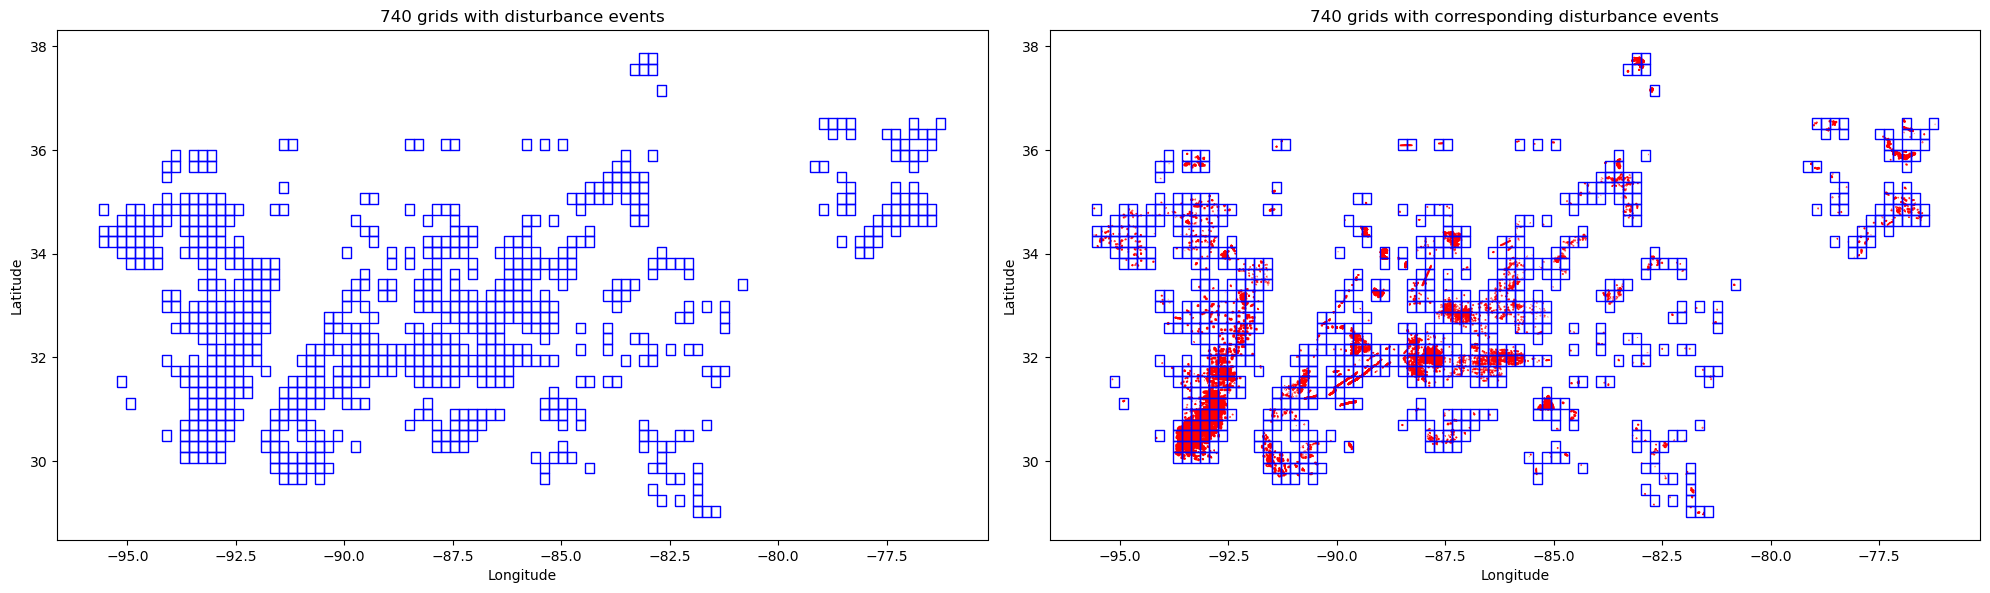

In [94]:
import geopandas as gpd
import matplotlib.pyplot as plt

def plot_combined(intersected_gdf, convex_hulls_gdf):
   
   # Step 2: Plot the intersected grids and convex hulls
    fig, axs = plt.subplots(1, 2, figsize=(20, 10))

    # Plot intersected grids in the first subplot
    intersected_gdf.boundary.plot(ax=axs[0], edgecolor='blue', linewidth=1)
    axs[0].set_title(f"{len(intersected_gdf)} grids with disturbance events")
    axs[0].set_xlabel('Longitude')
    axs[0].set_ylabel('Latitude')

    # Plot intersecting convex hulls in the second subplot
    convex_hulls_gdf.boundary.plot(ax=axs[1], edgecolor='red', linewidth=1)
    intersected_gdf.boundary.plot(ax=axs[1], edgecolor='blue', linewidth=1)
    axs[1].set_title(f"{len(intersected_gdf)} grids with corresponding disturbance events")
    axs[1].set_xlabel('Longitude')
    axs[1].set_ylabel('Latitude')

    plt.tight_layout()
    plt.show()


plot_combined(intersected, convex_hulls)
